# Credit Card Customer Segmentation Using K-Means Clustering

**Objective:**  
To segment credit card customers into meaningful groups based on their financial and spending behaviour using the K-Means clustering algorithm.

**Problem Type:** Unsupervised Learning – Clustering

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading

The credit card customer dataset is loaded into a Pandas DataFrame for analysis and clustering.

In [ ]:
uploaded = files.upload()

Saving clustering_data.csv to clustering_data.csv


In [ ]:
file_name = next(iter(uploaded))

# Use read_excel for .xlsx files
# Use read_csv for .csv files

if file_name.endswith(".xlsx"):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 2. Data Cleaning & Preprocessing

The dataset is inspected to understand its structure, data types, missing values and duplicate records before applying clustering.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 8950
Number of columns: 18

Column names:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [ ]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

print("\nTotal missing values:", missing.sum())

Columns with missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total missing values: 314


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (8950, 18)


### Removing Identifier

`CUST_ID` is only an identifier and does not represent customer behaviour. Therefore, it is excluded from clustering.

In [ ]:
df = df.drop(columns=["CUST_ID"], errors="ignore")

print("CUST_ID removed.")

CUST_ID removed.


## 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand customer spending, credit usage and payment behaviour before clustering.

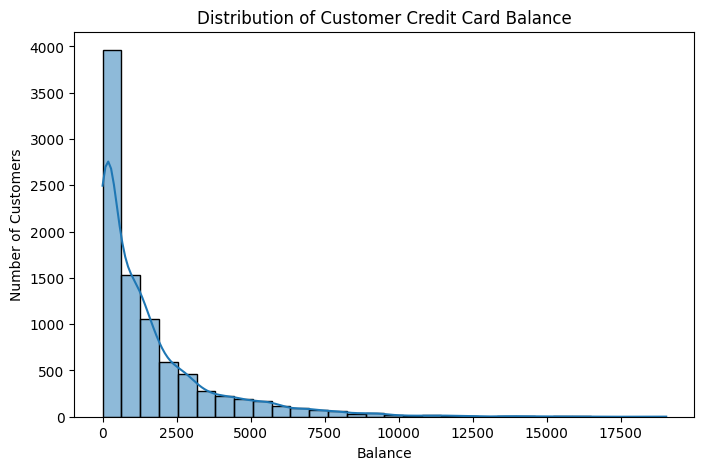

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="BALANCE",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Credit Card Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.show()

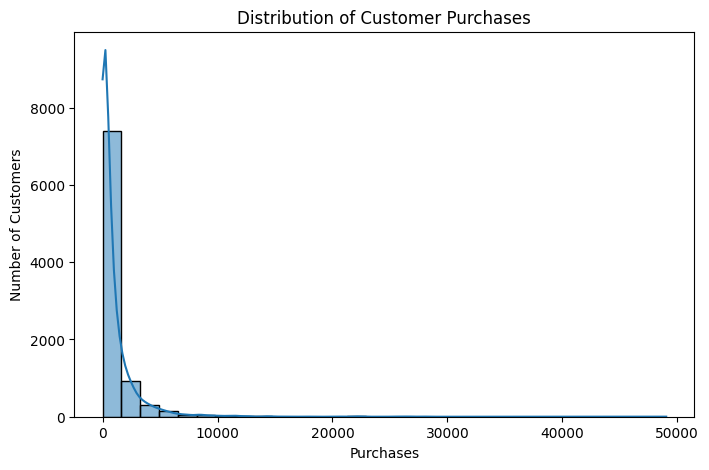

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="PURCHASES",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Purchases")
plt.xlabel("Purchases")
plt.ylabel("Number of Customers")

plt.show()

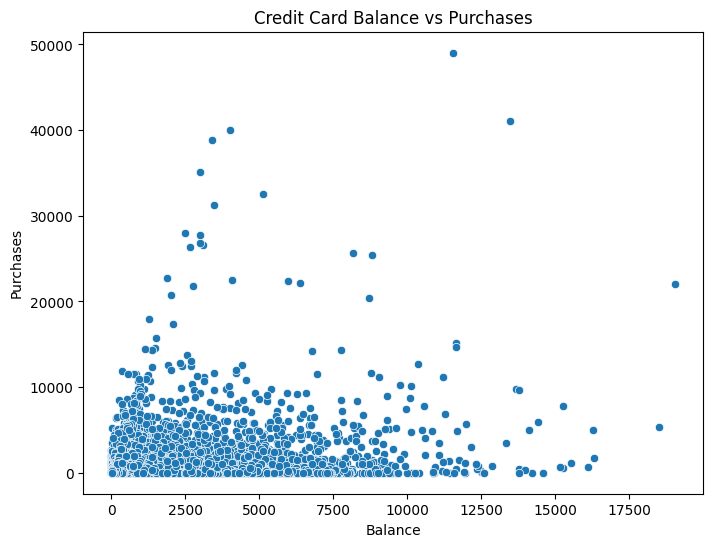

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="BALANCE",
    y="PURCHASES"
)

plt.title("Credit Card Balance vs Purchases")
plt.xlabel("Balance")
plt.ylabel("Purchases")

plt.show()

## 4. Feature Selection

For clustering, features related to customer financial behaviour are selected.

The following variables are used:

- BALANCE – customer's outstanding balance
- PURCHASES – total purchase amount
- CASH_ADVANCE – total cash advances
- CREDIT_LIMIT – customer's credit limit
- PAYMENTS – total payments made

In [ ]:
selected_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

X = df[selected_features].copy()

print("Selected features:")
print(selected_features)

print("\nShape of selected data:", X.shape)

Selected features:
['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

Shape of selected data: (8950, 5)


## 5. Data Standardization

K-Means uses distance to determine similarity between customers.

Since the selected variables have different scales, StandardScaler is used so that no single feature dominates the distance calculation.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed successfully!")

Standardization completed successfully!


## 6. Selecting the Optimal Number of Clusters

The Elbow Method is used to determine a suitable value of K.

The method calculates the Within-Cluster Sum of Squares for different values of K.

The point where the decrease starts slowing down is considered the elbow and gives a suitable number of clusters.

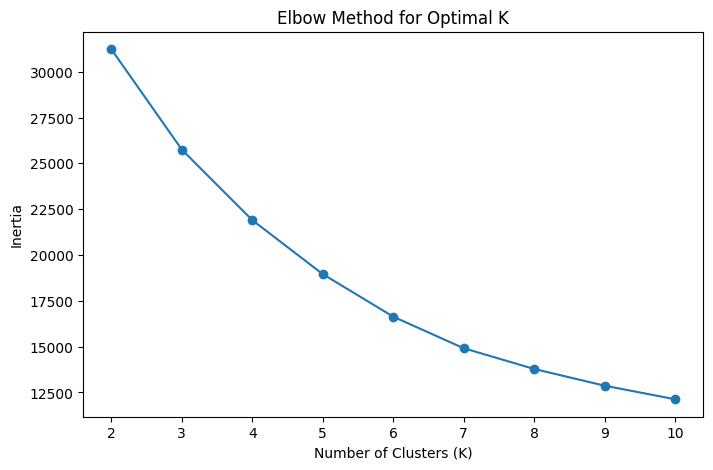

In [ ]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.566
K = 3: Silhouette Score = 0.512
K = 4: Silhouette Score = 0.404
K = 5: Silhouette Score = 0.437
K = 6: Silhouette Score = 0.373
K = 7: Silhouette Score = 0.384
K = 8: Silhouette Score = 0.378
K = 9: Silhouette Score = 0.389
K = 10: Silhouette Score = 0.340


## Optimal Number of Clusters

The Elbow Method was first used to examine the reduction in inertia for different values of K.

Since the elbow was not sharply defined, the Silhouette Score was additionally calculated to support the selection of K.

The highest Silhouette Score was obtained for **K = 2**, with a score of **0.566**.

Therefore, **K = 2** is selected as the final number of clusters.

## 7. K-Means Clustering

K-Means clustering is applied using the number of clusters selected from the Elbow Method and Silhouette Score Method.

Each customer is assigned to the cluster whose centroid is closest to the customer based on the standardized financial behaviour features.

In [ ]:
optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


In [ ]:
print("Number of customers in each cluster:")

print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)

Number of customers in each cluster:
Cluster
0    1418
1    7532
Name: count, dtype: int64


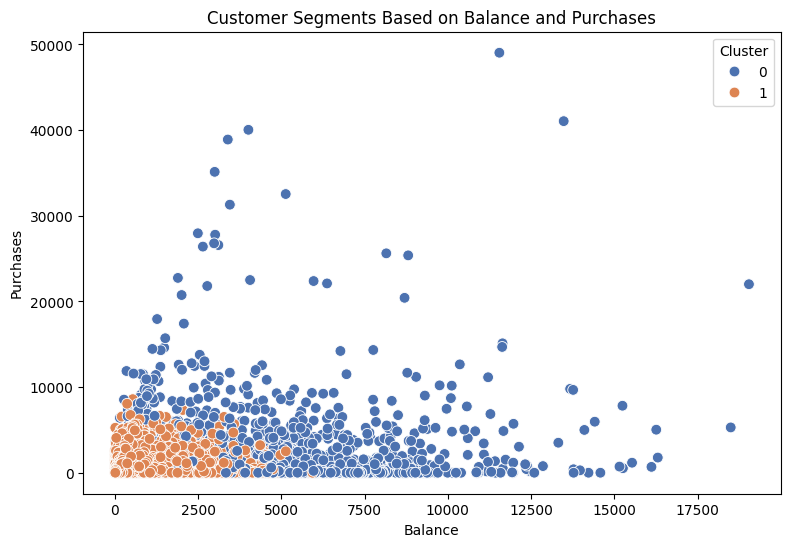

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="BALANCE",
    y="PURCHASES",
    hue="Cluster",
    palette="deep",
    s=60
)

plt.title("Customer Segments Based on Balance and Purchases")
plt.xlabel("Balance")
plt.ylabel("Purchases")

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[selected_features].mean().round(2)

cluster_summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
0,4863.76,2561.82,3545.86,9796.23,5106.44
1,943.34,709.77,495.60,3496.12,1098.08


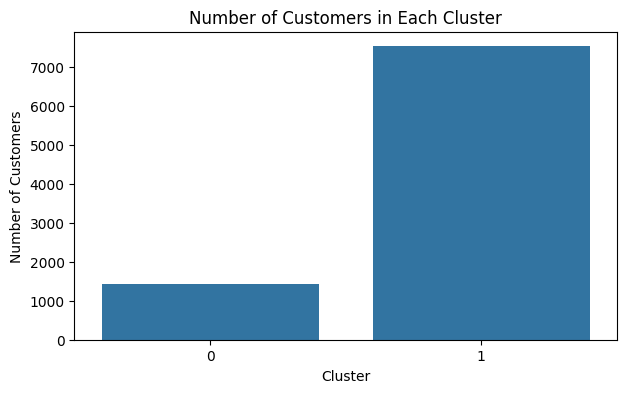

In [ ]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

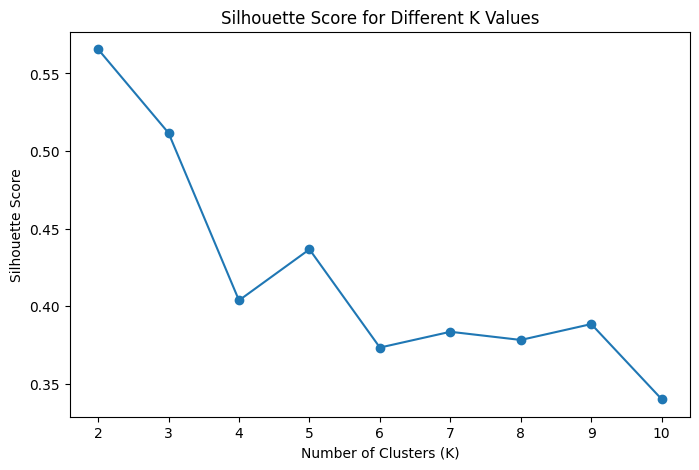

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

## 9. Results and Interpretation

K-Means clustering grouped customers according to similarities in their credit card financial behaviour.

The clusters were formed using balance, purchases, cash advances, credit limit and payment behaviour.

The cluster summary was used to understand the characteristics of each customer segment.

These segments can help financial institutions understand different customer groups and design suitable products, services and marketing strategies.